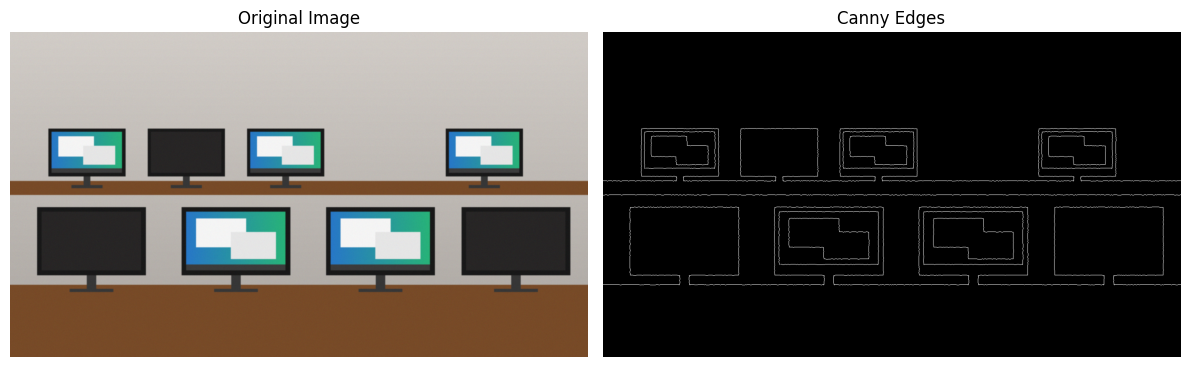

Total lines: 308
Horizontal lines: 54
Vertical lines: 37


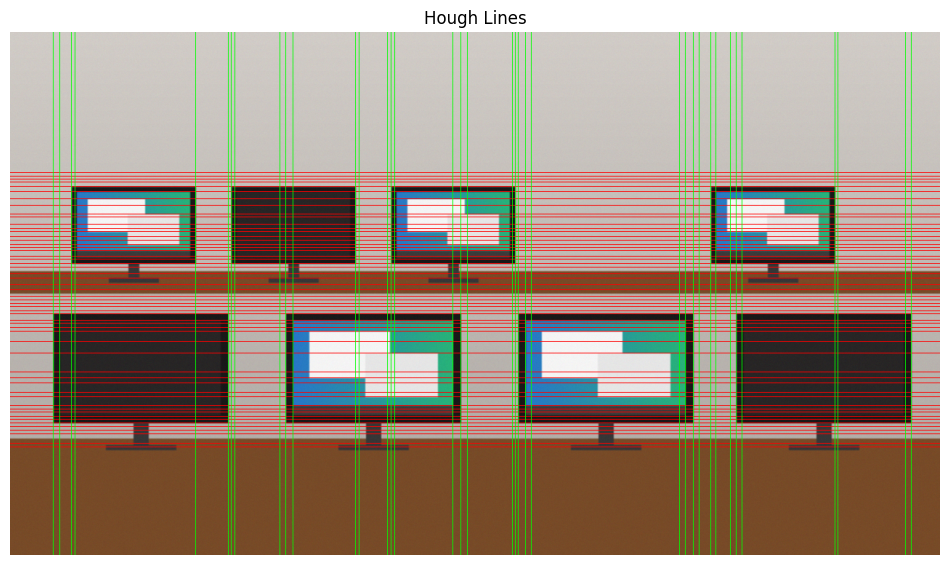

Screens found: 8
R1-1 ON 214.9
R1-2 OFF 40.2
R1-3 ON 214.9
R1-4 ON 214.9
R2-1 OFF 40.2
R2-2 ON 214.7
R2-3 ON 214.7
R2-4 OFF 40.2
Screens ON: 5
Screens OFF: 3
Missing screens: 1


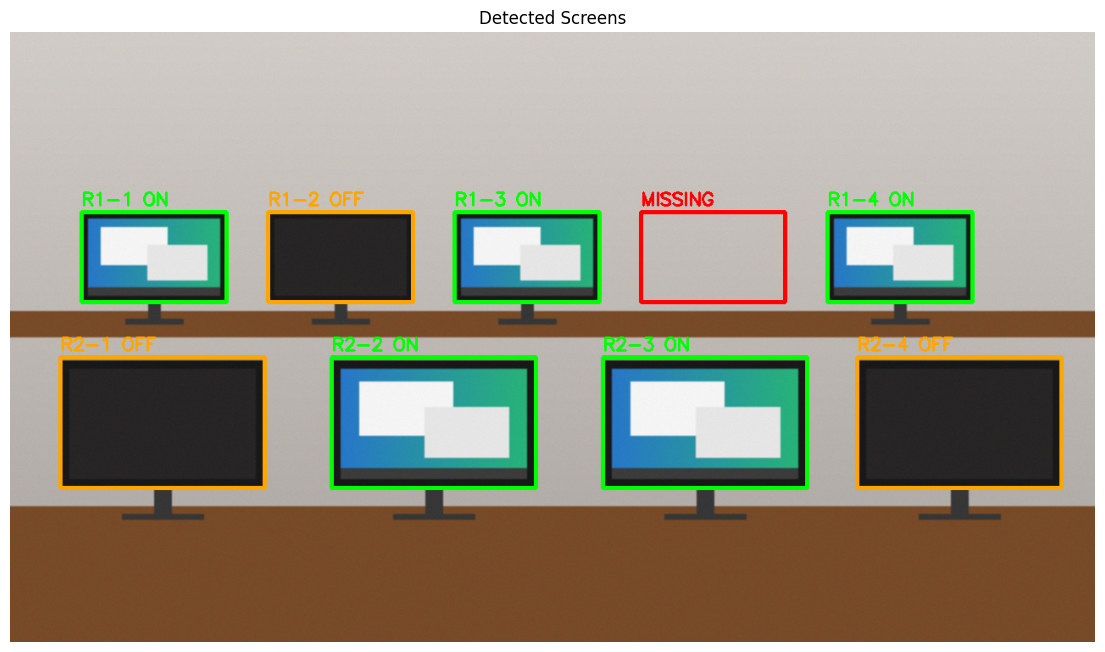

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
image = cv2.imread("computer_lab.png")

# Convert BGR to RGB for Matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Gaussian blur to remove noise
blurred = cv2.GaussianBlur(gray, (5, 5), 1.4)

# Canny edge detection
edges = cv2.Canny(blurred, 50, 150)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edges")
plt.axis("off")

plt.tight_layout()
plt.show()

# Hough line transform
lines = cv2.HoughLines(edges, 1, np.pi / 180, 60)
lines = lines.reshape(-1, 2)
print("Total lines:", len(lines))

# screen borders are only horizontal or vertical
horizontal = []
vertical = []
for rho, theta in lines:
    angle = np.degrees(theta)
    if abs(angle - 90) < 2:
        horizontal.append(int(rho))
    elif angle < 2 or angle > 178:
        vertical.append(int(abs(rho)))

# many lines come on the same edge, so keep only one
def remove_same(values):
    result = []
    for v in values:
        same = False
        for r in result:
            if abs(v - r) <= 3:
                same = True
        if same == False:
            result.append(v)
    result.sort()
    return result

horizontal = remove_same(horizontal)
vertical = remove_same(vertical)

# desk lines go across the whole image so remove them
thick_edges = cv2.dilate(edges, np.ones((5, 5), np.uint8))
desk = []
for y in horizontal:
    if (thick_edges[y] > 0).mean() > 0.9:
        desk.append(y)
for y in desk:
    horizontal.remove(y)

print("Horizontal lines:", len(horizontal))
print("Vertical lines:", len(vertical))

# Draw the lines
line_image = image_rgb.copy()
h, w = gray.shape
for y in horizontal:
    cv2.line(line_image, (0, y), (w, y), (255, 0, 0), 1)
for x in vertical:
    cv2.line(line_image, (x, 0), (x, h), (0, 255, 0), 1)

plt.figure(figsize=(12, 7))
plt.imshow(line_image)
plt.title("Hough Lines")
plt.axis("off")
plt.show()

# Find screens
# take 2 horizontal and 2 vertical lines, if all 4 sides are on edges then it is a screen
edge_check = cv2.dilate(edges, np.ones((7, 7), np.uint8)) > 0
boxes = []

for i in range(len(horizontal)):
    for j in range(i + 1, len(horizontal)):
        y1 = horizontal[i]
        y2 = horizontal[j]
        box_h = y2 - y1
        if box_h < 50 or box_h > 300:
            continue

        for a in range(len(vertical)):
            for b in range(a + 1, len(vertical)):
                x1 = vertical[a]
                x2 = vertical[b]
                box_w = x2 - x1

                # monitor is wider than its height
                if box_w / box_h < 1.2 or box_w / box_h > 2.2:
                    continue

                top = edge_check[y1, x1:x2].mean()
                bottom = edge_check[y2, x1:x2].mean()
                left = edge_check[y1:y2, x1].mean()
                right = edge_check[y1:y2, x2].mean()

                if top > 0.85 and bottom > 0.85 and left > 0.85 and right > 0.85:
                    boxes.append((x1, y1, box_w, box_h))

# remove a box if it is inside another box (screen inside the monitor border)
screens = []
for b1 in boxes:
    inside = False
    for b2 in boxes:
        if b1 != b2:
            if b1[0] >= b2[0] - 3 and b1[1] >= b2[1] - 3 and b1[0] + b1[2] <= b2[0] + b2[2] + 3 and b1[1] + b1[3] <= b2[1] + b2[3] + 3:
                inside = True
    if inside == False:
        screens.append(b1)

print("Screens found:", len(screens))

# Put screens in rows (front row and back row)
screens.sort(key=lambda s: s[1])
rows = []
for s in screens:
    if len(rows) > 0 and abs(s[1] - rows[-1][0][1]) < 60:
        rows[-1].append(s)
    else:
        rows.append([s])

# Check ON / OFF and missing screens
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
result = image_rgb.copy()
on_count = 0
off_count = 0
missing_count = 0

for r in range(len(rows)):
    row = rows[r]
    row.sort(key=lambda s: s[0])

    for k in range(len(row)):
        x, y, bw, bh = row[k]

        # brightness of the middle part of the screen
        middle = hsv[y + bh // 6 : y + bh - bh // 6, x + bw // 6 : x + bw - bw // 6, 2]
        brightness = middle.mean()

        if brightness > 80:
            status = "ON"
            color = (0, 255, 0)
            on_count += 1
        else:
            status = "OFF"
            color = (255, 165, 0)
            off_count += 1

        name = "R" + str(r + 1) + "-" + str(k + 1)
        print(name, status, round(brightness, 1))

        cv2.rectangle(result, (x, y), (x + bw, y + bh), color, 3)
        cv2.putText(result, name + " " + status, (x, y - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

    # missing screen: if gap between 2 screens is bigger than normal
    centers = []
    for s in row:
        centers.append(s[0] + s[2] / 2)
    gaps = np.diff(centers)
    if len(gaps) == 0:
        continue
    normal_gap = np.median(gaps)

    avg_w = int(np.mean([s[2] for s in row]))
    avg_h = int(np.mean([s[3] for s in row]))
    avg_y = int(np.mean([s[1] for s in row]))

    for k in range(len(gaps)):
        empty = int(round(gaps[k] / normal_gap)) - 1
        for m in range(empty):
            cx = int(centers[k] + normal_gap * (m + 1))
            missing_count += 1
            cv2.rectangle(result, (cx - avg_w // 2, avg_y), (cx + avg_w // 2, avg_y + avg_h), (255, 0, 0), 3)
            cv2.putText(result, "MISSING", (cx - avg_w // 2, avg_y - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)

print("Screens ON:", on_count)
print("Screens OFF:", off_count)
print("Missing screens:", missing_count)

plt.figure(figsize=(14, 8))
plt.imshow(result)
plt.title("Detected Screens")
plt.axis("off")
plt.show()